SWASTHIKA M 24BAD121


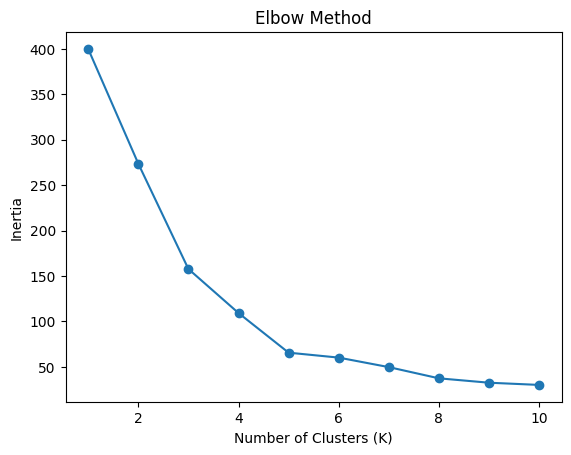

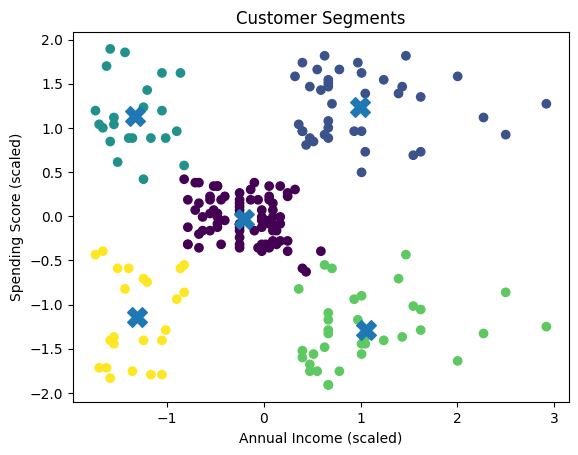

Silhouette Score: 0.5546571631111091


In [ ]:
#scenario 1
print("SWASTHIKA M 24BAD121")
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 2. Load dataset
data = pd.read_csv("Mall_Customers.csv")

# 3. Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# 4. Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 6. Apply K-Means (choose K=5 typically)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 7. Assign cluster labels
data['Cluster'] = labels

# 8. Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# 9. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

SWASTHIKA M 24BAD121


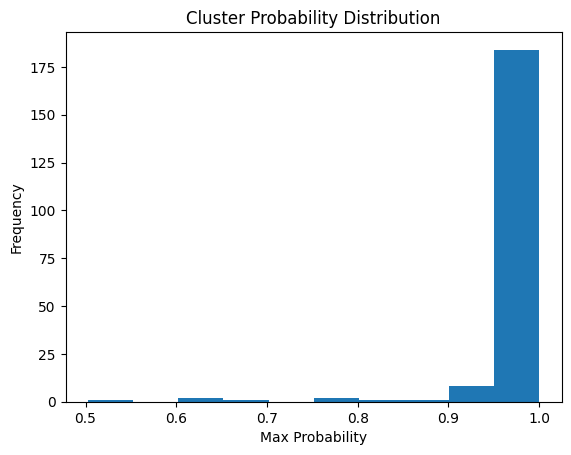

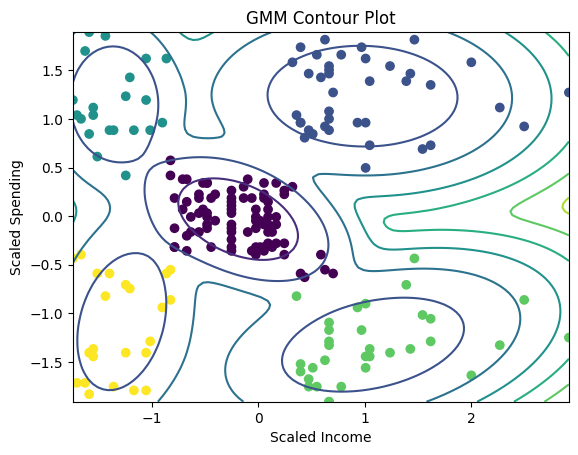

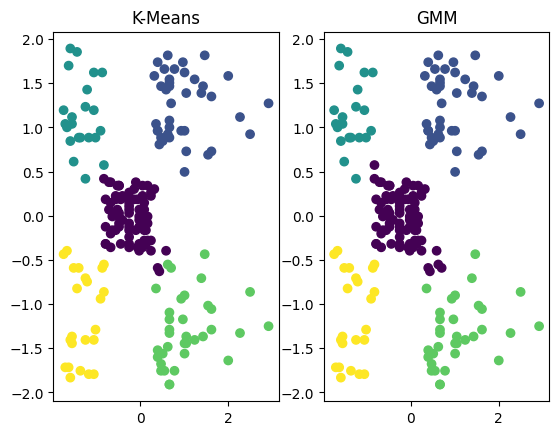

In [2]:
print("SWASTHIKA M 24BAD121")
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Get probabilities and labels
probs = gmm.predict_proba(X_scaled)
gmm_labels = gmm.predict(X_scaled)


# 1. Cluster Probability Distribution
plt.figure()
plt.hist(probs.max(axis=1), bins=10)
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.title('Cluster Probability Distribution')
plt.show()

# 2. GMM Contour Plot
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.c_[X_grid.ravel(), Y_grid.ravel()]

Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.xlabel('Scaled Income')
plt.ylabel('Scaled Spending')
plt.title('GMM Contour Plot')
plt.show()

# 3. Comparison Plot (K-Means vs GMM)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title('K-Means')

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.title('GMM')

plt.show()